# SOC Triage Model — `train/hehehihi.ipynb`
COS30018 Option D · SOC Triage ML pipeline

**This is an ML-based SOC Triage model, not a final attack detector.** It
estimates the likelihood that a network flow belongs to one of 7 traffic
categories and produces a confidence-weighted risk score, priority, and
recommended action for a downstream Detection LlmAgent. The Detection Agent
is responsible for validating each prediction — using additional context
such as CTI, MITRE ATT&CK knowledge, historical events, and further
reasoning — before making the final security decision. This model provides
evidence and prioritization only; it is not responsible for final attack
attribution.

This notebook is a **post-training refactor** of the already-executed
`afterTraining/notebooke402613643.ipynb` run: the trained XGBoost model, the
preprocessing pipeline, and every evaluation number (macro-F1, PR curves,
confusion matrices, SHAP, latency) are carried over **unchanged, with no
retraining**. Only §13 (Output Contract) and the model card are refactored
so the model's output reads as **triage evidence** rather than an
authoritative verdict.

**Dataset:** `dhoogla/cicids2017` Kaggle **Version 2** (no-metadata parquet,
one file per attack day/category), as originally loaded in the source run.

**Stop gates (by design — report, don't edit the gate):**
1. Schema gate — exactly `EXPECTED_N_FEATURES = 77` feature columns.
2. Label gate — every raw label must map to one of the 7 categories.
   **Heartbleed does not map and halts the notebook**; it is excluded only
   after you explicitly set `ACKNOWLEDGE_HEARTBLEED = True`.
3. Leakage guard — no flow id / IP / port / timestamp / label-derived column
   may survive into the feature set, and nothing fits before the split.


# 1. Setup

In [1]:
!pip -q install xgboost shap >/dev/null 2>&1

import os, glob, json, time, random, hashlib
from datetime import datetime, timezone

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
import sklearn, xgboost, shap

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

DATA_DIR = "/kaggle/input"    
OUT_DIR = "/kaggle/working"
os.makedirs(OUT_DIR, exist_ok=True)

EXPECTED_N_FEATURES = 77
LABEL_COL = "Label"
CATEGORIES = ["benign", "dos_ddos", "port_scan", "brute_force",
              "web_attack", "botnet", "infiltration"]
MODEL_VERSION = "triage-xgb-1.0.0"

print("numpy", np.__version__, "| pandas", pd.__version__,
      "| sklearn", sklearn.__version__, "| xgboost", xgboost.__version__,
      "| shap", shap.__version__)
print("DATA_DIR:", DATA_DIR, "| OUT_DIR:", OUT_DIR, "| SEED:", SEED)

numpy 2.0.2 | pandas 2.3.3 | sklearn 1.6.1 | xgboost 3.2.0 | shap 0.51.0
DATA_DIR: /kaggle/input | OUT_DIR: /kaggle/working | SEED: 42


# 2. Load Dataset

In [2]:
parquet_files = sorted(glob.glob(os.path.join(DATA_DIR, "**", "*.parquet"), recursive=True))
if not parquet_files:
    raise SystemExit(f"STOP: no .parquet files under {DATA_DIR} — "
                     "attach dhoogla/cicids2017 (Version 2, no-metadata) as a notebook input.")

frames = []
for p in parquet_files:
    f = pd.read_parquet(p)
    f.columns = [str(c).strip() for c in f.columns]
    print(f"{os.path.basename(p):<45} {f.shape}")
    frames.append(f)
df = pd.concat(frames, ignore_index=True)
del frames
print("\ncombined:", df.shape)

Benign-Monday-no-metadata.parquet             (458831, 78)
Botnet-Friday-no-metadata.parquet             (176038, 78)
Bruteforce-Tuesday-no-metadata.parquet        (389714, 78)
DDoS-Friday-no-metadata.parquet               (221264, 78)
DoS-Wednesday-no-metadata.parquet             (584991, 78)
Infiltration-Thursday-no-metadata.parquet     (207630, 78)
Portscan-Friday-no-metadata.parquet           (119522, 78)
WebAttacks-Thursday-no-metadata.parquet       (155820, 78)

combined: (2313810, 78)


In [3]:
print("dtypes:")
print(df.dtypes.value_counts(), "\n")

if LABEL_COL not in df.columns:
    raise SystemExit(f"STOP: no '{LABEL_COL}' column. Columns: {list(df.columns)}")
print("raw label counts:")
print(df[LABEL_COL].value_counts())

dtypes:
int32      26
float32    22
int8       19
int16       7
float64     2
int64       1
object      1
Name: count, dtype: int64 

raw label counts:
Label
Benign                        1977318
DoS Hulk                       172846
DDoS                           128014
DoS GoldenEye                   10286
FTP-Patator                      5931
DoS slowloris                    5385
DoS Slowhttptest                 5228
SSH-Patator                      3219
PortScan                         1956
Web Attack � Brute Force         1470
Bot                              1437
Web Attack � XSS                  652
Infiltration                       36
Web Attack � Sql Injection         21
Heartbleed                         11
Name: count, dtype: int64


# 3. Schema Gate

In [4]:
feature_cols = [c for c in df.columns if c != LABEL_COL]
if len(feature_cols) != EXPECTED_N_FEATURES:
    for i, c in enumerate(df.columns):
        print(f"{i:>3} {c}")
    raise SystemExit(f"STOP: {len(feature_cols)} feature columns != {EXPECTED_N_FEATURES}. "
                     "Report the full column list above before continuing.")
print(f"schema gate OK: {len(feature_cols)} feature columns")

schema gate OK: 77 feature columns


# 4. Data Cleaning
Duplicates and constant columns dropped, Inf converted to NaN. No imputation yet — that is fit post-split, on train only.

In [5]:
n0 = len(df)
df = df.drop_duplicates().reset_index(drop=True)
print(f"duplicate rows dropped: {n0 - len(df):,}  ({n0:,} -> {len(df):,})")

duplicate rows dropped: 82,004  (2,313,810 -> 2,231,806)


In [6]:
constant_cols = [c for c in feature_cols if df[c].nunique(dropna=False) <= 1]
df = df.drop(columns=constant_cols)
feature_cols = [c for c in feature_cols if c not in constant_cols]
print(f"constant columns dropped: {len(constant_cols)} {constant_cols}")
print(f"feature columns remaining: {len(feature_cols)}")

constant columns dropped: 8 ['Bwd PSH Flags', 'Bwd URG Flags', 'Fwd Avg Bytes/Bulk', 'Fwd Avg Packets/Bulk', 'Fwd Avg Bulk Rate', 'Bwd Avg Bytes/Bulk', 'Bwd Avg Packets/Bulk', 'Bwd Avg Bulk Rate']
feature columns remaining: 69


In [7]:
df[feature_cols] = df[feature_cols].replace([np.inf, -np.inf], np.nan)
nan_per_col = df[feature_cols].isna().sum()
n_nan_cols = int((nan_per_col > 0).sum())
print(f"NaN cells after Inf->NaN: {int(nan_per_col.sum()):,} across {n_nan_cols} columns")
if n_nan_cols:
    print(nan_per_col[nan_per_col > 0].to_string())
else:
    print("(no NaN present — the post-split imputer below stays as a safety net)")

NaN cells after Inf->NaN: 0 across 0 columns
(no NaN present — the post-split imputer below stays as a safety net)


# 5. Label Engineering
Keyword matching survives CICIDS2017's dash/space/case variants; `web_attack` must match before `brute_force` ("Web Attack - Brute Force").

In [8]:
def to_category(label):
    s = " ".join(str(label).strip().lower()
                 .replace("\u2013", "-").replace("\u2014", "-").split())
    if s == "benign":                             return "benign"
    if "web attack" in s or "web-attack" in s:    return "web_attack"
    if "brute" in s or "patator" in s:            return "brute_force"
    if "portscan" in s or "port scan" in s:       return "port_scan"
    if "ddos" in s or "dos" in s:                 return "dos_ddos"
    if "bot" in s:                                return "botnet"
    if "infiltration" in s:                       return "infiltration"
    return None

label_map = {raw: to_category(raw) for raw in df[LABEL_COL].unique()}
for raw, cat in sorted(label_map.items(), key=lambda kv: str(kv[1])):
    print(f"{str(raw)!r:<42} -> {cat}")

'Heartbleed'                               -> None
'Benign'                                   -> benign
'Bot'                                      -> botnet
'FTP-Patator'                              -> brute_force
'SSH-Patator'                              -> brute_force
'DDoS'                                     -> dos_ddos
'DoS slowloris'                            -> dos_ddos
'DoS Slowhttptest'                         -> dos_ddos
'DoS Hulk'                                 -> dos_ddos
'DoS GoldenEye'                            -> dos_ddos
'Infiltration'                             -> infiltration
'PortScan'                                 -> port_scan
'Web Attack � Brute Force'                 -> web_attack
'Web Attack � XSS'                         -> web_attack
'Web Attack � Sql Injection'               -> web_attack


In [9]:
ACKNOWLEDGE_HEARTBLEED = True   # set True after reading the STOP message, then re-run this cell

unmapped = [raw for raw, cat in label_map.items() if cat is None]
heartbleed_labels = [r for r in unmapped if "heartbleed" in str(r).lower()]
other_unmapped = [r for r in unmapped if r not in heartbleed_labels]
if other_unmapped:
    raise SystemExit(f"STOP: unmapped non-Heartbleed labels {other_unmapped} — "
                     "extend the taxonomy, never bucket or drop silently.")

hb_mask = df[LABEL_COL].isin(heartbleed_labels)
n_heartbleed = int(hb_mask.sum())
print(f"Heartbleed rows found: {n_heartbleed:,}")

if n_heartbleed and not ACKNOWLEDGE_HEARTBLEED:
    raise SystemExit(
        "STOP: 'Heartbleed' does not map to any of the 7 project categories.\n"
        f"{n_heartbleed} rows are quarantined, NOT silently dropped.\n"
        "Per the project spec it stays outside the taxonomy.\n"
        "Set ACKNOWLEDGE_HEARTBLEED = True above and re-run this cell to exclude the rows;\n"
        "the exclusion is recorded in results.json and the model card."
    )

heartbleed_df = df[hb_mask].copy()
df = df[~hb_mask].reset_index(drop=True)
df["category"] = df[LABEL_COL].map(label_map)
assert df["category"].notna().all()
print(f"excluded {n_heartbleed} Heartbleed rows (kept in heartbleed_df); remaining: {len(df):,}")
print("\ncategory distribution:")
print(df["category"].value_counts().reindex(CATEGORIES, fill_value=0))

Heartbleed rows found: 11
excluded 11 Heartbleed rows (kept in heartbleed_df); remaining: 2,231,795

category distribution:
category
benign          1895314
dos_ddos         321759
port_scan          1956
brute_force        9150
web_attack         2143
botnet             1437
infiltration         36
Name: count, dtype: int64


# 6. Leakage Guard

In [10]:
LEAKAGE_PATTERNS = ["flow id", "src ip", "source ip", "dst ip", "destination ip",
                    "src port", "source port", "dst port", "destination port",
                    "timestamp", "label"]
leaked = [c for c in feature_cols if any(p in c.lower() for p in LEAKAGE_PATTERNS)]
if leaked:
    raise SystemExit(f"STOP: potential leakage columns in features: {leaked}")
assert LABEL_COL not in feature_cols and "category" not in feature_cols

FITTING_ALLOWED = False   # flipped True only by the split cell; every fit asserts on it
print(f"leakage guard OK: no id/ip/port/timestamp/label columns among {len(feature_cols)} features")

leakage guard OK: no id/ip/port/timestamp/label columns among 69 features


# 7. Train/Val/Test Split
Stratified 70/15/15, seed 42. Labels encoded to the canonical `CATEGORIES` order.

In [11]:
from sklearn.model_selection import train_test_split

X = df[feature_cols]
y = df["category"].map({c: i for i, c in enumerate(CATEGORIES)}).to_numpy()

X_trainval, X_test, y_train_val, y_test = train_test_split(
    X, y, test_size=0.15, stratify=y, random_state=SEED)
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_train_val, test_size=0.15 / 0.85, stratify=y_train_val, random_state=SEED)

FITTING_ALLOWED = True
for name, yy in [("train", y_train), ("val", y_val), ("test", y_test)]:
    counts = np.bincount(yy, minlength=len(CATEGORIES))
    print(f"{name:<5} {len(yy):>9,} rows | "
          + " ".join(f"{c}:{n:,}" for c, n in zip(CATEGORIES, counts)))

train 1,562,255 rows | benign:1,326,718 dos_ddos:225,231 port_scan:1,369 brute_force:6,405 web_attack:1,500 botnet:1,006 infiltration:26
val     334,770 rows | benign:284,298 dos_ddos:48,264 port_scan:294 brute_force:1,372 web_attack:322 botnet:215 infiltration:5
test    334,770 rows | benign:284,298 dos_ddos:48,264 port_scan:293 brute_force:1,373 web_attack:321 botnet:216 infiltration:5


# 8. Imputation & Scaling
Fit on **train only**, post-split. Saved as `preprocessor.joblib` for the serving path.

In [12]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

assert FITTING_ALLOWED, "split must run before any fitting"

preprocessor = Pipeline([
    ("impute", SimpleImputer(strategy="median")),
    ("scale", StandardScaler()),
])
Xtr = preprocessor.fit_transform(X_train).astype(np.float32)   # fit on train ONLY
Xva = preprocessor.transform(X_val).astype(np.float32)
Xte = preprocessor.transform(X_test).astype(np.float32)

joblib.dump(preprocessor, os.path.join(OUT_DIR, "preprocessor.joblib"))
print("preprocessor fit on train only — saved preprocessor.joblib")
print("shapes:", Xtr.shape, Xva.shape, Xte.shape)

preprocessor fit on train only — saved preprocessor.joblib
shapes: (1562255, 69) (334770, 69) (334770, 69)


# 9. Baselines
Logistic Regression and Random Forest, evaluated on the **validation** split (the test split is touched once, in Evaluation).

In [13]:
from sklearn.metrics import f1_score, classification_report, confusion_matrix

results = {}

def evaluate(name, model, X_eval, y_true):
    pred = model.predict(X_eval)
    macro = f1_score(y_true, pred, average="macro")
    results[name] = {
        "macro_f1": round(float(macro), 4),
        "per_class": classification_report(y_true, pred, labels=range(len(CATEGORIES)),
                                           target_names=CATEGORIES, output_dict=True,
                                           zero_division=0),
    }
    print(f"=== {name} — macro-F1 {macro:.4f} ===")
    print(classification_report(y_true, pred, labels=range(len(CATEGORIES)),
                                target_names=CATEGORIES, digits=3, zero_division=0))
    print("confusion matrix (rows=true, cols=pred):")
    print(pd.DataFrame(confusion_matrix(y_true, pred, labels=range(len(CATEGORIES))),
                       index=CATEGORIES, columns=CATEGORIES))
    return pred

print("evaluate() ready — results collected into `results`")

evaluate() ready — results collected into `results`


In [14]:
from sklearn.linear_model import LogisticRegression

assert FITTING_ALLOWED
t0 = time.perf_counter()
logreg = LogisticRegression(max_iter=1000, class_weight="balanced", random_state=SEED)
logreg.fit(Xtr, y_train)
print(f"LogisticRegression trained in {time.perf_counter() - t0:.0f}s")
evaluate("logreg_val", logreg, Xva, y_val);

LogisticRegression trained in 699s
=== logreg_val — macro-F1 0.3953 ===
              precision    recall  f1-score   support

      benign      0.998     0.852     0.919    284298
    dos_ddos      0.833     0.979     0.900     48264
   port_scan      0.109     0.932     0.195       294
 brute_force      0.505     0.970     0.664      1372
  web_attack      0.019     0.957     0.036       322
      botnet      0.027     0.972     0.052       215
infiltration      0.001     0.800     0.001         5

    accuracy                          0.871    334770
   macro avg      0.356     0.923     0.395    334770
weighted avg      0.970     0.871     0.913    334770

confusion matrix (rows=true, cols=pred):
              benign  dos_ddos  port_scan  brute_force  web_attack  botnet  \
benign        242161      9473       2224         1290       16215    7590   
dos_ddos         519     47237         19           17          59      19   
port_scan          1        12        274            0  

In [15]:
from sklearn.ensemble import RandomForestClassifier

assert FITTING_ALLOWED
t0 = time.perf_counter()
rf = RandomForestClassifier(n_estimators=100, max_depth=25, min_samples_leaf=5,
                            class_weight="balanced", n_jobs=-1, random_state=SEED)
rf.fit(Xtr, y_train)
print(f"RandomForest trained in {time.perf_counter() - t0:.0f}s")
evaluate("rf_val", rf, Xva, y_val);

RandomForest trained in 299s
=== rf_val — macro-F1 0.8778 ===
              precision    recall  f1-score   support

      benign      1.000     0.998     0.999    284298
    dos_ddos      0.997     0.998     0.998     48264
   port_scan      0.956     0.969     0.963       294
 brute_force      0.996     0.990     0.993      1372
  web_attack      0.975     0.953     0.964       322
      botnet      0.319     0.963     0.479       215
infiltration      1.000     0.600     0.750         5

    accuracy                          0.998    334770
   macro avg      0.892     0.924     0.878    334770
weighted avg      0.999     0.998     0.998    334770

confusion matrix (rows=true, cols=pred):
              benign  dos_ddos  port_scan  brute_force  web_attack  botnet  \
benign        283697       138         10            6           5     442   
dos_ddos          93     48167          3            0           1       0   
port_scan          3         4        285            0           2

# 10. XGBoost
Small grid tuned on a stratified subsample of train with early stopping on the
**validation** split, then the best config is refit on train+val at the best
iteration count. Uses GPU automatically if the Kaggle accelerator is on.

In [16]:
from xgboost import XGBClassifier
from sklearn.utils.class_weight import compute_sample_weight
import shutil

DEVICE = "cuda" if shutil.which("nvidia-smi") else "cpu"

TUNE_MAX_ROWS = 300_000
if len(Xtr) > TUNE_MAX_ROWS:
    Xtune, _, ytune, _ = train_test_split(Xtr, y_train, train_size=TUNE_MAX_ROWS,
                                          stratify=y_train, random_state=SEED)
else:
    Xtune, ytune = Xtr, y_train
w_tune = compute_sample_weight("balanced", ytune)
print(f"device: {DEVICE} | tuning on {len(ytune):,} of {len(y_train):,} train rows")

param_grid = [{"max_depth": d, "learning_rate": lr} for d in (6, 8, 10) for lr in (0.1, 0.3)]
tuning = []
for params in param_grid:
    assert FITTING_ALLOWED
    m = XGBClassifier(n_estimators=300, early_stopping_rounds=20, tree_method="hist",
                      device=DEVICE, eval_metric="mlogloss", random_state=SEED,
                      n_jobs=-1, **params)
    m.fit(Xtune, ytune, sample_weight=w_tune, eval_set=[(Xva, y_val)], verbose=False)
    macro = f1_score(y_val, m.predict(Xva), average="macro")
    tuning.append({**params, "best_iteration": int(m.best_iteration),
                   "val_macro_f1": round(float(macro), 4)})
    print(tuning[-1])

best = max(tuning, key=lambda t: t["val_macro_f1"])
print("\nbest config:", best)

device: cpu | tuning on 300,000 of 1,562,255 train rows
{'max_depth': 6, 'learning_rate': 0.1, 'best_iteration': 299, 'val_macro_f1': 0.9148}
{'max_depth': 6, 'learning_rate': 0.3, 'best_iteration': 201, 'val_macro_f1': 0.9191}
{'max_depth': 8, 'learning_rate': 0.1, 'best_iteration': 299, 'val_macro_f1': 0.9377}
{'max_depth': 8, 'learning_rate': 0.3, 'best_iteration': 165, 'val_macro_f1': 0.9168}
{'max_depth': 10, 'learning_rate': 0.1, 'best_iteration': 299, 'val_macro_f1': 0.916}
{'max_depth': 10, 'learning_rate': 0.3, 'best_iteration': 125, 'val_macro_f1': 0.916}

best config: {'max_depth': 8, 'learning_rate': 0.1, 'best_iteration': 299, 'val_macro_f1': 0.9377}


In [17]:
final_params = {"max_depth": best["max_depth"], "learning_rate": best["learning_rate"]}
n_rounds = best["best_iteration"] + 1

Xtrv = np.vstack([Xtr, Xva])
ytrv = np.concatenate([y_train, y_val])
w_trv = compute_sample_weight("balanced", ytrv)

t0 = time.perf_counter()
final_model = XGBClassifier(n_estimators=n_rounds, tree_method="hist", device=DEVICE,
                            eval_metric="mlogloss", random_state=SEED, n_jobs=-1,
                            **final_params)
final_model.fit(Xtrv, ytrv, sample_weight=w_trv, verbose=False)
final_model.set_params(device="cpu")   # inference on CPU — matches SOC deployment
print(f"final XGBoost: {n_rounds} rounds, params {final_params}, "
      f"fit on train+val ({len(ytrv):,} rows) in {time.perf_counter() - t0:.0f}s")

final XGBoost: 300 rounds, params {'max_depth': 8, 'learning_rate': 0.1}, fit on train+val (1,897,025 rows) in 414s


# 11. Evaluation
All three models reported once on the held-out **test** split.

In [18]:
pred_lr = evaluate("logreg_test", logreg, Xte, y_test)
pred_rf = evaluate("rf_test", rf, Xte, y_test)
pred_xgb = evaluate("xgboost_test", final_model, Xte, y_test)

=== logreg_test — macro-F1 0.3933 ===
              precision    recall  f1-score   support

      benign      0.998     0.852     0.919    284298
    dos_ddos      0.835     0.978     0.901     48264
   port_scan      0.110     0.956     0.197       293
 brute_force      0.482     0.969     0.644      1373
  web_attack      0.019     0.994     0.037       321
      botnet      0.027     0.986     0.053       216
infiltration      0.001     0.600     0.001         5

    accuracy                          0.871    334770
   macro avg      0.353     0.905     0.393    334770
weighted avg      0.970     0.871     0.913    334770

confusion matrix (rows=true, cols=pred):
              benign  dos_ddos  port_scan  brute_force  web_attack  botnet  \
benign        242197      9299       2250         1408       16322    7524   
dos_ddos         523     47203         16           20          40      36   
port_scan          0         9        280            0           2       2   
brute_force 

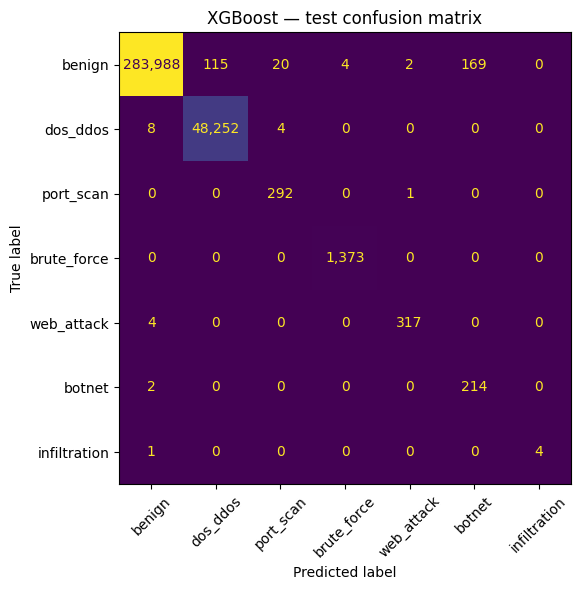

rows = true category, cols = predicted


In [19]:
from sklearn.metrics import ConfusionMatrixDisplay

fig, ax = plt.subplots(figsize=(7, 6))
ConfusionMatrixDisplay.from_predictions(y_test, pred_xgb, display_labels=CATEGORIES,
                                        xticks_rotation=45, ax=ax, colorbar=False,
                                        values_format=",")
ax.set_title("XGBoost — test confusion matrix")
plt.tight_layout()
plt.show()
print("rows = true category, cols = predicted")

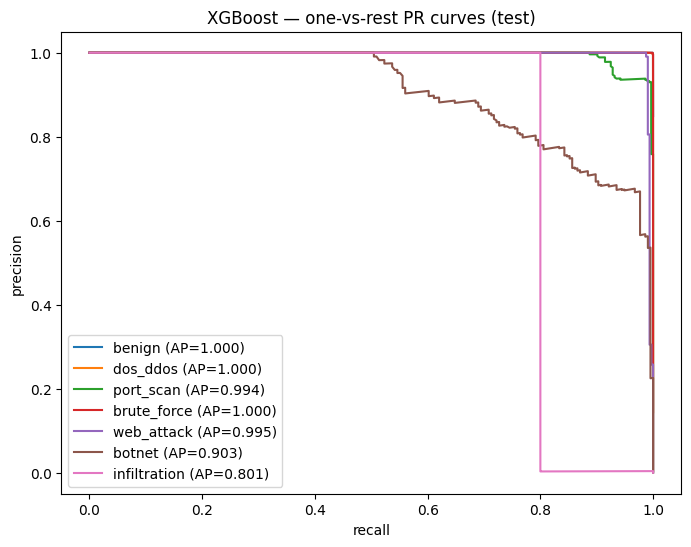

{'benign': 1.0, 'dos_ddos': 1.0, 'port_scan': 0.9943, 'brute_force': 1.0, 'web_attack': 0.9949, 'botnet': 0.9031, 'infiltration': 0.8008}


In [20]:
from sklearn.metrics import precision_recall_curve, average_precision_score

proba_xgb = final_model.predict_proba(Xte)
fig, ax = plt.subplots(figsize=(8, 6))
ap_per_class = {}
for i, cat in enumerate(CATEGORIES):
    y_bin = (y_test == i).astype(int)
    prec, rec, _ = precision_recall_curve(y_bin, proba_xgb[:, i])
    ap = average_precision_score(y_bin, proba_xgb[:, i])
    ap_per_class[cat] = round(float(ap), 4)
    ax.plot(rec, prec, label=f"{cat} (AP={ap:.3f})")
ax.set_xlabel("recall"); ax.set_ylabel("precision")
ax.set_title("XGBoost — one-vs-rest PR curves (test)")
ax.legend(loc="lower left")
plt.show()

results["average_precision"] = ap_per_class
print(ap_per_class)

In [21]:
t0 = time.perf_counter()
_ = final_model.predict_proba(Xte)
batch_ms_per_flow = (time.perf_counter() - t0) / len(Xte) * 1000

one = Xte[:1]
_ = final_model.predict_proba(one)   # warm-up
t0 = time.perf_counter()
for _i in range(200):
    _ = final_model.predict_proba(one)
single_flow_ms = (time.perf_counter() - t0) / 200 * 1000

results["latency"] = {"batch_ms_per_flow": round(batch_ms_per_flow, 4),
                      "single_flow_ms": round(single_flow_ms, 3)}
print(results["latency"])

{'batch_ms_per_flow': 0.0229, 'single_flow_ms': 1.797}


# 12. SHAP
Global importance from mean |SHAP| over a 2,000-row test sample and all classes, plus one local explanation for a predicted attack.

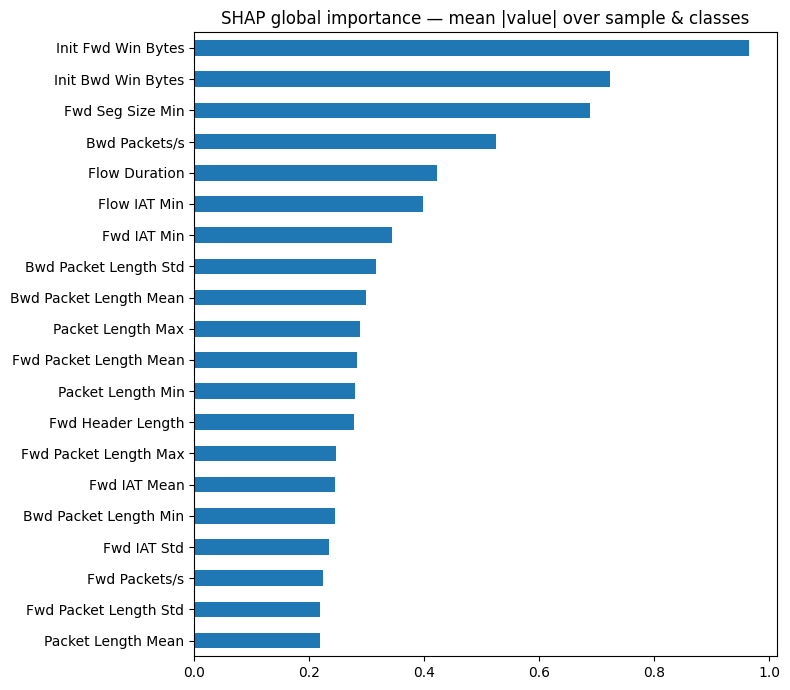

Init Fwd Win Bytes        0.9646
Init Bwd Win Bytes        0.7234
Fwd Seg Size Min          0.6881
Bwd Packets/s             0.5248
Flow Duration             0.4227
Flow IAT Min              0.3976
Fwd IAT Min               0.3438
Bwd Packet Length Std     0.3164
Bwd Packet Length Mean    0.2995
Packet Length Max         0.2884


In [22]:
rng = np.random.default_rng(SEED)
shap_idx = rng.choice(len(Xte), size=min(2000, len(Xte)), replace=False)
X_shap = Xte[shap_idx]

explainer = shap.TreeExplainer(final_model)
sv = explainer.shap_values(X_shap)
sv = np.stack(sv, axis=-1) if isinstance(sv, list) else sv   # -> (n_rows, n_features, n_classes)

global_imp = pd.Series(np.abs(sv).mean(axis=(0, 2)), index=feature_cols).sort_values()
global_imp.tail(20).plot.barh(figsize=(8, 7),
                              title="SHAP global importance — mean |value| over sample & classes")
plt.tight_layout()
plt.show()
print(global_imp.tail(10)[::-1].round(4).to_string())

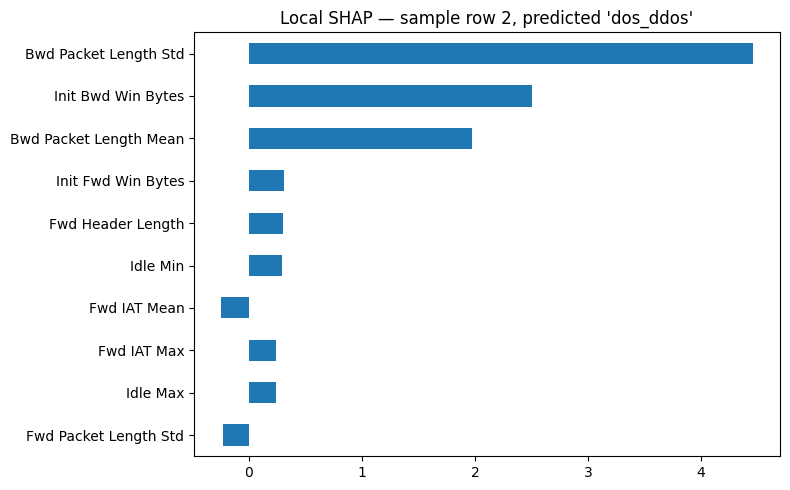

true=dos_ddos | predicted=dos_ddos
Bwd Packet Length Std     4.4644
Init Bwd Win Bytes        2.5078
Bwd Packet Length Mean    1.9783
Init Fwd Win Bytes        0.3074
Fwd Header Length         0.2990
Idle Min                  0.2947
Fwd IAT Mean             -0.2494
Fwd IAT Max               0.2417
Idle Max                  0.2388
Fwd Packet Length Std    -0.2333


In [23]:
pred_sample = final_model.predict(X_shap)
local_i = int(np.argmax(pred_sample != 0)) if (pred_sample != 0).any() else 0
cls = int(pred_sample[local_i])

contrib = pd.Series(sv[local_i, :, cls], index=feature_cols)
top = contrib.reindex(contrib.abs().sort_values().tail(10).index)
top.plot.barh(figsize=(8, 5),
              title=f"Local SHAP — sample row {local_i}, predicted '{CATEGORIES[cls]}'")
plt.tight_layout()
plt.show()
print(f"true={CATEGORIES[int(y_test[shap_idx][local_i])]} | predicted={CATEGORIES[cls]}")
print(top[::-1].round(4).to_string())

# 13. Output Contract — Triage Evidence for the Detection Agent
`triage_output` is **ML-based SOC Triage** evidence, not a final verdict —
it is consumed downstream via `session_state["triage_output"]` by a
Detection LlmAgent, which validates it against CTI, MITRE ATT&CK knowledge,
historical events, and further reasoning before making the final security
decision.

Schema: `event_id`, `predicted_category`, `confidence`, `risk_score`,
`priority`, `severity_score`, `recommended_action`, `entities`,
`model_version`.

- `predicted_category` — predicted traffic class
- `confidence` — predicted probability of the chosen class
- `severity_score` — category base severity × confidence
- `risk_score` — confidence-weighted attack likelihood (here, equal to
  `severity_score`)
- `priority` — Low / Medium / High, derived from `severity_score`
  (0–1 Low, 1–3 Medium, 3–5 High)
- `recommended_action` — `"archive"` / `"queue_detection"` /
  `"escalate_detection"`, derived from `priority`
- `entities` — always null for CICIDS2017 benchmark runs; populated only
  during live capture
- `model_version` — identifies the (unmodified) trained model artifact


In [24]:
SEVERITY_BASE = {
    "benign": 0.0, "port_scan": 2.0, "brute_force": 3.0, "dos_ddos": 4.0,
    "web_attack": 4.0, "botnet": 5.0, "infiltration": 5.0,
}

def derive_priority(severity_score):
    """Low/Medium/High banding used to route triage evidence, not a verdict."""
    if severity_score < 1:
        return "Low"
    if severity_score < 3:
        return "Medium"
    return "High"

def derive_recommended_action(priority):
    return {"Low": "archive", "Medium": "queue_detection",
            "High": "escalate_detection"}[priority]

def build_triage_output(event_id, proba_row):
    # ML-based SOC Triage evidence for the Detection LlmAgent — not a final
    # attack verdict. The Detection Agent corroborates this with CTI, MITRE
    # ATT&CK knowledge, historical events and further reasoning before
    # making the final security decision.
    i = int(np.argmax(proba_row))
    predicted_category = CATEGORIES[i]
    confidence = float(proba_row[i])
    severity_score = round(SEVERITY_BASE[predicted_category] * confidence, 4)
    risk_score = severity_score
    priority = derive_priority(severity_score)
    recommended_action = derive_recommended_action(priority)
    return {
        "event_id": str(event_id),
        "predicted_category": predicted_category,
        "confidence": round(confidence, 4),
        "risk_score": risk_score,
        "priority": priority,
        "severity_score": severity_score,
        "recommended_action": recommended_action,
        "entities": {"src_ip": None, "dst_ip": None, "dst_port": None, "protocol": None},
        "model_version": MODEL_VERSION,
    }

demo_rows = [int(np.argmax(pred_xgb == 0)), int(np.argmax(pred_xgb != 0))]
demo = [build_triage_output(f"evt-{j:06d}", proba_xgb[j]) for j in demo_rows]
print(json.dumps(demo, indent=2))


[
  {
    "event_id": "evt-000000",
    "predicted_category": "benign",
    "confidence": 0.9999,
    "risk_score": 0.0,
    "priority": "Low",
    "severity_score": 0.0,
    "recommended_action": "archive",
    "entities": {
      "src_ip": null,
      "dst_ip": null,
      "dst_port": null,
      "protocol": null
    },
    "model_version": "triage-xgb-1.0.0"
  },
  {
    "event_id": "evt-000019",
    "predicted_category": "dos_ddos",
    "confidence": 1.0,
    "risk_score": 4.0,
    "priority": "High",
    "severity_score": 4.0,
    "recommended_action": "escalate_detection",
    "entities": {
      "src_ip": null,
      "dst_ip": null,
      "dst_port": null,
      "protocol": null
    },
    "model_version": "triage-xgb-1.0.0"
  }
]


# 14. Export
`model.joblib`, `preprocessor.joblib` (saved in §8), `results.json`,
`model_card.md` — all under `OUT_DIR`. The exported model artifact,
preprocessor and evaluation metrics are byte-for-byte the same as the
source (`afterTraining`) run — only `results.json`'s `severity_base` and
`model_card.md` change, to reflect the triage output contract.


In [25]:
joblib.dump(final_model, os.path.join(OUT_DIR, "model.joblib"))

h = hashlib.sha256()
h.update(pd.util.hash_pandas_object(df[sorted(feature_cols)], index=False).values.tobytes())
data_hash = h.hexdigest()[:16]

results.update({
    "model_version": MODEL_VERSION,
    "seed": SEED,
    "source_dataset": "dhoogla/cicids2017 (version 2, no-metadata)",
    "generated_at": datetime.now(timezone.utc).isoformat(),
    "data_hash": data_hash,
    "n_rows_after_cleaning": int(len(df)),
    "heartbleed_rows_excluded": n_heartbleed,
    "constant_cols_dropped": constant_cols,
    "n_features": len(feature_cols),
    "feature_cols": feature_cols,
    "categories": CATEGORIES,
    "severity_base": SEVERITY_BASE,
    "split": {"train": int(len(y_train)), "val": int(len(y_val)), "test": int(len(y_test))},
    "xgb_tuning_log": tuning,
    "xgb_best": best,
})
with open(os.path.join(OUT_DIR, "results.json"), "w") as f:
    json.dump(results, f, indent=2, default=str)

print("saved model.joblib + results.json")
print("test macro-F1 — logreg:", results["logreg_test"]["macro_f1"],
      "| rf:", results["rf_test"]["macro_f1"],
      "| xgboost:", results["xgboost_test"]["macro_f1"])

saved model.joblib + results.json
test macro-F1 — logreg: 0.3933 | rf: 0.8798 | xgboost: 0.9354


In [26]:
model_card = f"""# Model Card — SOC Triage Model `{MODEL_VERSION}`

## Overview
This is an **ML-based SOC Triage model** for COS30018 Option D — not a final
attack detector. It estimates the likelihood that a network flow belongs to
one of seven traffic categories ({", ".join(CATEGORIES)}) and produces a
confidence-weighted risk score, priority level, and recommended action. It
is intended for rapid filtering and prioritization of network flows,
forwarding high-risk events — via `session_state["triage_output"]` — to a
downstream Detection LlmAgent.

**This model is intended for triage and prioritization rather than final
attack confirmation.** The Detection LlmAgent is responsible for validating
each prediction using additional context such as CTI, MITRE ATT&CK
knowledge, historical events, and further reasoning before making the final
security decision. This model provides evidence, not a verdict, and is not
responsible for final attack attribution.

## Data
- Source: dhoogla/cicids2017, Kaggle Version 2 (no-metadata parquet)
- Rows after cleaning: {len(df):,} (duplicates + constant columns removed, Inf -> NaN)
- Heartbleed rows excluded (outside the 7-class taxonomy, per spec): {n_heartbleed}
- Features: {len(feature_cols)} | data hash: `{data_hash}`
- Split: stratified 70/15/15, seed {SEED}

## Method
- Preprocessing: median imputation + standard scaling, fit on train only
- Baselines: Logistic Regression, Random Forest (class-weight balanced)
- Final model: XGBoost (hist), tuned on validation with early stopping,
  refit on train+val at {best["best_iteration"] + 1} rounds,
  params {final_params}, balanced sample weights

## Test results (macro F1)
| model | macro F1 |
|---|---|
| Logistic Regression | {results["logreg_test"]["macro_f1"]} |
| Random Forest | {results["rf_test"]["macro_f1"]} |
| **XGBoost** | **{results["xgboost_test"]["macro_f1"]}** |

Latency: {results["latency"]["single_flow_ms"]} ms/flow single,
{results["latency"]["batch_ms_per_flow"]} ms/flow batched (CPU).
Per-class metrics, PR curves and confusion matrices: see `results.json` and notebook.

## Kaggle-notebook flaws avoided
1. **Leakage via bootstrap resampling** — no resampling at all; duplicates are
   removed *before* the split so no identical flow lands in both train and
   test. Imbalance is handled with class/sample weights instead.
2. **Scaler fit on the test set** — imputer and scaler are fit on the training
   split only, then applied to val/test.
3. **CV / tuning on the test set** — hyperparameters were selected on the
   validation split; the test split was used exactly once, for final reporting.
4. **Missing random state** — seed {SEED} fixed for numpy, all splits and
   every model.

## Output contract
`triage_output`: event_id, predicted_category, confidence, risk_score,
priority, severity_score, recommended_action, entities, model_version.

- `predicted_category` — predicted traffic class
- `confidence` — predicted probability of the chosen class
- `risk_score` — confidence-weighted attack likelihood (here, equal to `severity_score`)
- `priority` — Low / Medium / High, derived from `severity_score` (0-1 Low, 1-3 Medium, 3-5 High)
- `severity_score` — category base severity x confidence; base severity: {SEVERITY_BASE}
- `recommended_action` — "archive" / "queue_detection" / "escalate_detection", derived from `priority`
- `entities` — null for CICIDS2017 benchmark runs (populated only during live capture)
- `model_version`

## Role in the SOC pipeline
This model is the **triage stage**, not the final classifier. It filters and
prioritizes the flood of network flows so the Detection LlmAgent — which
reasons over CTI, MITRE ATT&CK knowledge, historical events, and other
context this model does not see — can focus on the events most likely to
matter. A high `risk_score` / `priority` is a request for analysis, not an
attack confirmation.

## Limitations
- Trained on 2017 benchmark traffic; distribution shift expected on live networks.
- `infiltration` has very few samples — its metrics are noisy.
- Heartbleed is not covered by the taxonomy and is not detected by this model.
- This model does not make the final security decision — its
  `predicted_category`/`risk_score`/`priority` are inputs to the downstream
  Detection LlmAgent, which must corroborate them (CTI, MITRE ATT&CK,
  historical events, reasoning) before confirming an attack.
"""

with open(os.path.join(OUT_DIR, "model_card.md"), "w") as f:
    f.write(model_card)
print(model_card)


# Model Card — SOC Triage Model `triage-xgb-1.0.0`

## Overview
This is an **ML-based SOC Triage model** for COS30018 Option D — not a final
attack detector. It estimates the likelihood that a network flow belongs to
one of seven traffic categories (benign, dos_ddos, port_scan, brute_force,
web_attack, botnet, infiltration) and produces a confidence-weighted risk
score, priority level, and recommended action. It is intended for rapid
filtering and prioritization of network flows, forwarding high-risk events —
via `session_state["triage_output"]` — to a downstream Detection LlmAgent.

**This model is intended for triage and prioritization rather than final
attack confirmation.** The Detection LlmAgent is responsible for validating
each prediction using additional context such as CTI, MITRE ATT&CK
knowledge, historical events, and further reasoning before making the final
security decision. This model provides evidence, not a verdict, and is not
responsible for final attack attribution.


## Artifacts

- `model.joblib` — final XGBoost model (unchanged from the source run)
- `preprocessor.joblib` — median imputer + standard scaler, fit on train
  only (unchanged)
- `results.json` — all metrics, tuning log, split sizes, data hash, and the
  triage severity/priority mapping
- `model_card.md` — method, results, flaws avoided, limitations, and the
  triage output contract

Next step: wire `build_triage_output()` + these artifacts into the serving
path that fills `session_state["triage_output"]` for the Detection LlmAgent.
**The Detection LlmAgent — not this model — makes the final security
decision**, using this triage evidence plus CTI, MITRE ATT&CK knowledge,
historical events, and further reasoning.
